In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

Meilleurs paramètres KPPV : {'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'distance'}
Meilleurs paramètres SVM : {'C': 8, 'gamma': 10, 'kernel': 'sigmoid'}
RMSE KPPV : 63.09638137925841
RMSE SVM : 102.39029571229001


/var/folders/fn/0zxlxwm500b7hng2w4pssfbr0000gn/T/ipykernel_82195/1398248852.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=rmse_values, palette="viridis")


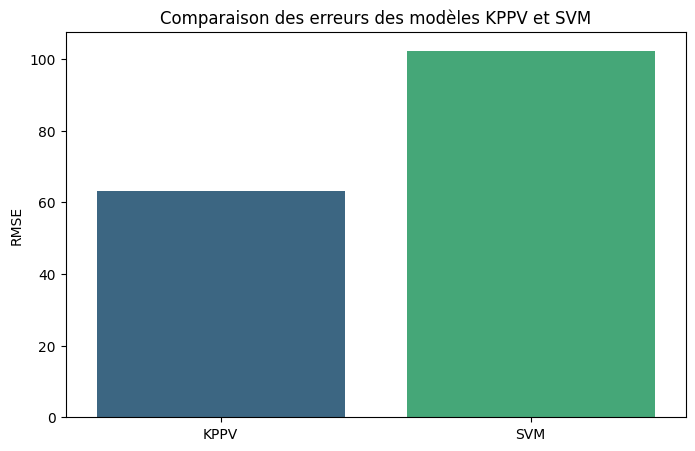

Prédictions KPPV :  [1824.05342203 1826.25556412 1735.53591799 1745.69540746 1754.44469503
 1803.50472988 1803.48844671 1746.96473441 1745.44265914 1803.45050682]
Prédictions SVM :  [1830.36666667 1807.09969889 1816.83273112 1800.83273112 1808.09969889
 1875.90060221 1900.63363444 1789.63363444 1808.09969889 1805.63363444]
RMSE KPPV (CV) : 104.92987662084658
RMSE SVM (CV) : 113.63500167738083


In [40]:
# Charger le dataframe AuteursNat.csv
df = pd.read_csv("data/AuteursNat.csv")
auteurs = pd.read_csv("data/Auteurs.csv", sep = " ")
# Sélectionner uniquement les colonnes où la première ligne (index 0) est "ADJ"
auteurs_adj = auteurs.loc[:, auteurs.iloc[0] == "ADJ"]
# Ajouter la colonne des auteurs
auteurs_adj.insert(0, "voc", auteurs["voc"])
# Supprimer la ligne d'étiquettes grammaticales
auteurs_adj = auteurs_adj.drop(index=0).reset_index(drop=True)



# Supposons que 'AnneeNaissance' est la colonne avec les années de naissance et les autres colonnes sont des caractéristiques.
# Remplacer "AnneeNaissance" par le nom exact de votre colonne si nécessaire.
#X = auteurs.drop(columns=["voc"]).iloc[1:].reset_index(drop=True).astype(float)   # Caractéristiques
X = auteurs_adj.drop(columns=["voc"]).astype(float)
y = df["Naissance"]  # Variable cible (année de naissance)

# Séparer les données en ensemble d'entraînement et ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----- Modèle KPPV -----
# Initialisation du modèle KPPV
kppv = KNeighborsRegressor()

# Optimisation des hyperparamètres de KPPV
param_grid_kppv = {
    "n_neighbors": [2, 3, 4, 5, 6, 7, 10, 15],  # Valeurs possibles de k
    "metric": ["euclidean", "manhattan", "minkowski"],  # Différentes métriques de distance
    "weights": ["uniform", "distance"]  # Poids des voisins
}

grid_search_kppv = GridSearchCV(kppv, param_grid_kppv, cv=5, n_jobs=-1)
grid_search_kppv.fit(X_train_scaled, y_train)

# Meilleurs paramètres et performance du modèle KPPV
print(f"Meilleurs paramètres KPPV : {grid_search_kppv.best_params_}")
kppv_best = grid_search_kppv.best_estimator_
y_pred_kppv = kppv_best.predict(X_test_scaled)

# ----- Modèle SVM -----
# Initialisation du modèle SVM
svm = SVR()

# Optimisation des hyperparamètres de SVM
param_grid_svm = {
    "kernel": ["linear", "poly", "rbf", "sigmoid"],  # Types de noyau
    "C": [0.1, 1, 3, 5, 8, 10, 100],  # Paramètre de régularisation
    "gamma": ["scale", "auto", 0.1, 1, 10]  # Paramètre gamma pour les noyaux non linéaires
}

grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, n_jobs=-1)
grid_search_svm.fit(X_train_scaled, y_train)

# Meilleurs paramètres et performance du modèle SVM
print(f"Meilleurs paramètres SVM : {grid_search_svm.best_params_}")
svm_best = grid_search_svm.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

# ----- Évaluation des modèles -----
# Calcul de l'erreur quadratique moyenne (RMSE) pour chaque modèle
rmse_kppv = np.sqrt(mean_squared_error(y_test, y_pred_kppv))
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))

print(f"RMSE KPPV : {rmse_kppv}")
print(f"RMSE SVM : {rmse_svm}")

# Comparaison des erreurs
models = ['KPPV', 'SVM']
rmse_values = [rmse_kppv, rmse_svm]

# Création d'un graphique de comparaison des RMSE
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=rmse_values, palette="viridis")
plt.ylabel('RMSE')
plt.title('Comparaison des erreurs des modèles KPPV et SVM')
plt.show()

# Afficher les prédictions
print("Prédictions KPPV : ", y_pred_kppv[:10])
print("Prédictions SVM : ", y_pred_svm[:10])

from sklearn.model_selection import cross_val_score
# Évaluation par validation croisée directement sur X_train
rmse_kppv_cv = np.sqrt(-cross_val_score(kppv_best, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error').mean())
rmse_svm_cv = np.sqrt(-cross_val_score(svm_best, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error').mean())

print(f"RMSE KPPV (CV) : {rmse_kppv_cv}")
print(f"RMSE SVM (CV) : {rmse_svm_cv}")


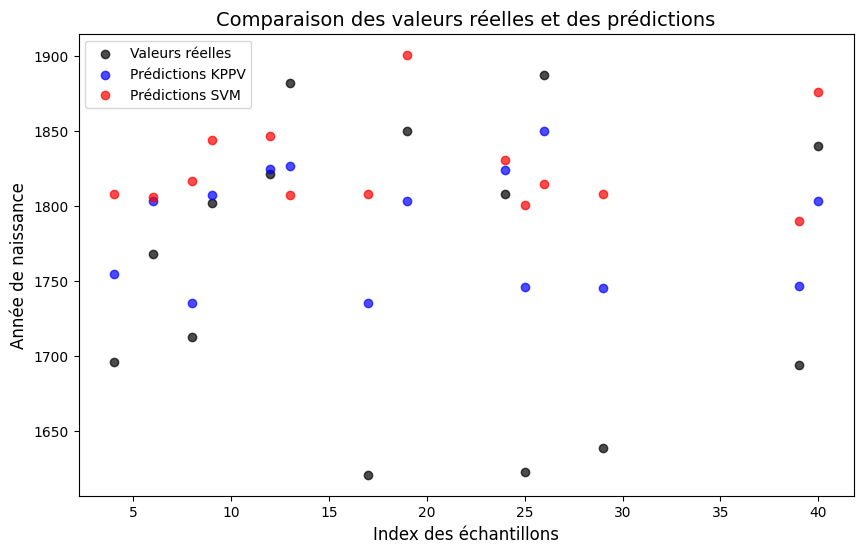

In [41]:
# Créer un DataFrame pour mieux gérer les données
results = pd.DataFrame({
    'Réel': y_test,
    'Prédiction KPPV': y_pred_kppv,
    'Prédiction SVM': y_pred_svm
})

# Créer un graphique de comparaison
plt.figure(figsize=(10, 6))

# Tracer les valeurs réelles
plt.scatter(results.index, results['Réel'], color='black', label='Valeurs réelles', alpha=0.7)

# Tracer les prédictions de KPPV
plt.scatter(results.index, results['Prédiction KPPV'], color='blue', label='Prédictions KPPV', alpha=0.7)

# Tracer les prédictions de SVM
plt.scatter(results.index, results['Prédiction SVM'], color='red', label='Prédictions SVM', alpha=0.7)

# Ajouter des titres et labels
plt.title('Comparaison des valeurs réelles et des prédictions', fontsize=14)
plt.xlabel('Index des échantillons', fontsize=12)
plt.ylabel('Année de naissance', fontsize=12)
plt.legend()

# Afficher le graphique
plt.show()

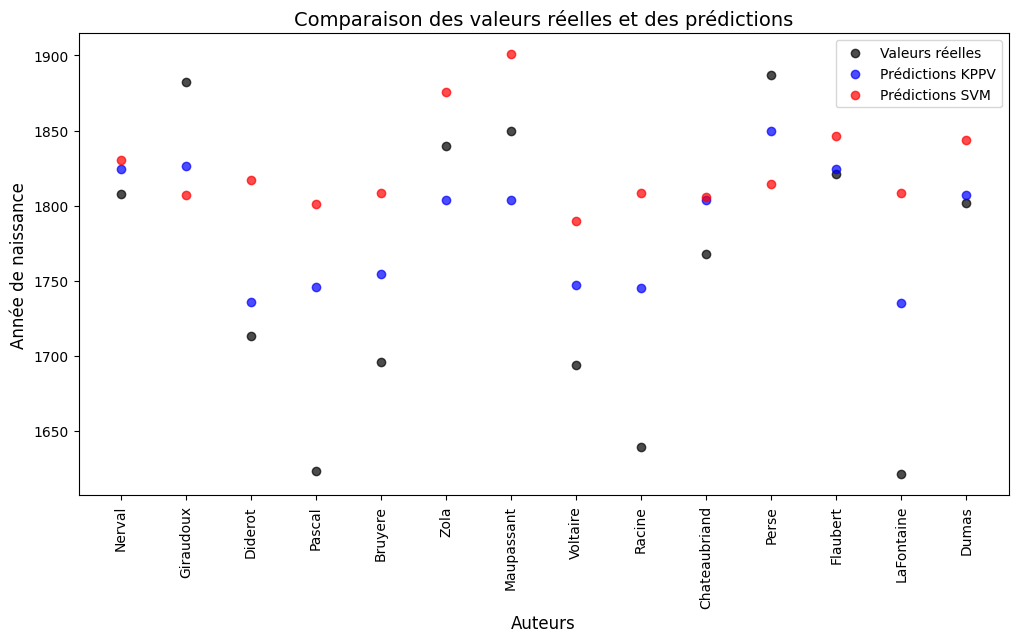

In [42]:
# Ajouter les noms des auteurs dans le DataFrame des résultats
results['Auteur'] = auteurs_adj["voc"].iloc[y_test.index].values  # Récupère les auteurs correspondant à y_test

# Créer un graphique de comparaison
plt.figure(figsize=(12, 6))

# Tracer les valeurs réelles
plt.scatter(results['Auteur'], results['Réel'], color='black', label='Valeurs réelles', alpha=0.7)

# Tracer les prédictions de KPPV
plt.scatter(results['Auteur'], results['Prédiction KPPV'], color='blue', label='Prédictions KPPV', alpha=0.7)

# Tracer les prédictions de SVM
plt.scatter(results['Auteur'], results['Prédiction SVM'], color='red', label='Prédictions SVM', alpha=0.7)

# Ajouter des titres et labels
plt.xticks(rotation=90)  # Faire pivoter les labels pour une meilleure lisibilité
plt.title('Comparaison des valeurs réelles et des prédictions', fontsize=14)
plt.xlabel('Auteurs', fontsize=12)
plt.ylabel('Année de naissance', fontsize=12)
plt.legend()

# Afficher le graphique
plt.show()
